In [1]:
# Load the CSVs
import pandas as pd
import numpy as np
train = pd.read_csv('fraudTrain.csv')
test = pd.read_csv('fraudTest.csv')

df = pd.concat([train, test], ignore_index=True)

In [4]:
# Step 3: Understand the data
df.shape    #(how many rows and columns)
df.info()   #(data types for each column and number of non-null values)
df.head()   #(just visualize the first 5 rows of data to understand the data)


<class 'pandas.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 23 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Unnamed: 0             int64  
 1   trans_date_trans_time  str    
 2   cc_num                 int64  
 3   merchant               str    
 4   category               str    
 5   amt                    float64
 6   first                  str    
 7   last                   str    
 8   gender                 str    
 9   street                 str    
 10  city                   str    
 11  state                  str    
 12  zip                    int64  
 13  lat                    float64
 14  long                   float64
 15  city_pop               int64  
 16  job                    str    
 17  dob                    str    
 18  trans_num              str    
 19  unix_time              int64  
 20  merch_lat              float64
 21  merch_long             float64
 22  is_fraud               int64 

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [16]:
# Step 4: Check data types
df.dtypes

Unnamed: 0                 int64
trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

In [ ]:
# Check duplicate values
df.duplicated().sum()
df['trans_num'].duplicated().sum()

np.int64(0)

In [18]:
# CHECK FOR NULL VALUES
df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [19]:
# REMOVE UNNESSARY COLUMNS
df.drop(columns=['Unnamed: 0', 'unix_time', 'street'], inplace=True)

In [20]:
# Step 8: Feature engineering — convert date columns
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

In [21]:
# CREATE THE DATE FEATURES AND DROP ORIGINAL DATE COLUMN AND CATEGORIZE INTO MONTHS YEAR,DAYS,HOURS,WEEKDAYS
# df['trans_year']    = df['trans_date_trans_time'].dt.year
df['trans_month']   = df['trans_date_trans_time'].dt.month
df['trans_day']     = df['trans_date_trans_time'].dt.day
df['trans_hour']    = df['trans_date_trans_time'].dt.hour
df['trans_weekday'] = df['trans_date_trans_time'].dt.day_name()

In [24]:
#Create Customer Age
df['customer_age'] = df['trans_date_trans_time'].dt.year - df['dob'].dt.year

In [25]:
# Create Amount Range (binning)
df['amount_range'] = pd.cut(
    df['amt'],
    bins=[0, 50, 100, 250, 500, 1000, 100000],
    labels=['0-50', '51-100', '101-250', '251-500', '501-1000', '1000+']
)

In [26]:
# Save the cleaned dataset
df.to_csv('fraud_cleaned.csv', index=False)

In [5]:
import matplotlib.pyplot as plt

In [7]:
import seaborn as sns
df = pd.read_csv('fraud_cleaned.csv')
sns.set_style('whitegrid')

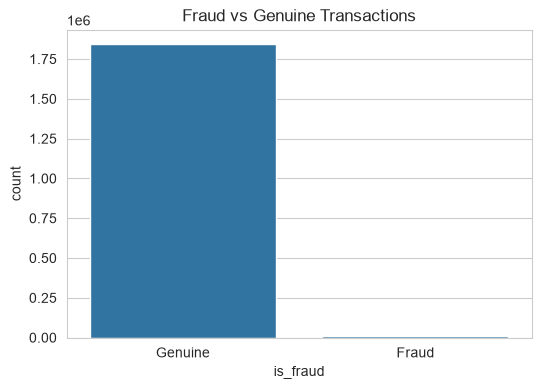

In [9]:

plt.figure(figsize=(6,4))# chart to visualize the distribution of fraud and genuine transactions
sns.countplot(data=df, x='is_fraud')
plt.title('Fraud vs Genuine Transactions')
plt.xticks([0,1], ['Genuine','Fraud'])
plt.show()

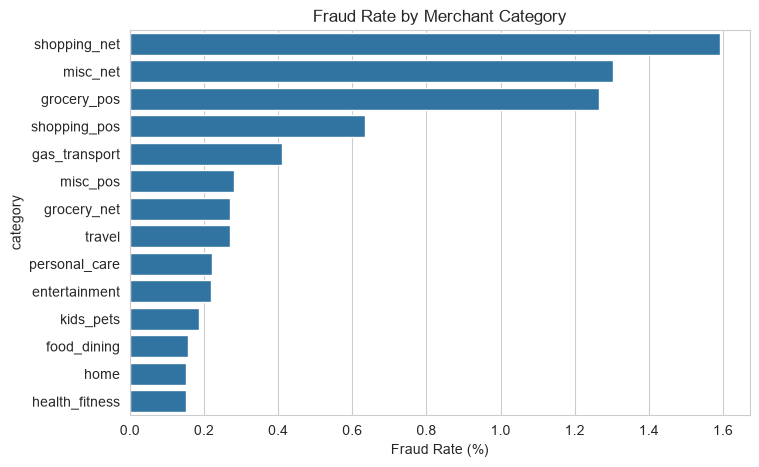

In [10]:
cat_fraud = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8,5))
sns.barplot(x=cat_fraud.values, y=cat_fraud.index)
plt.xlabel('Fraud Rate (%)')
plt.title('Fraud Rate by Merchant Category')
plt.show()

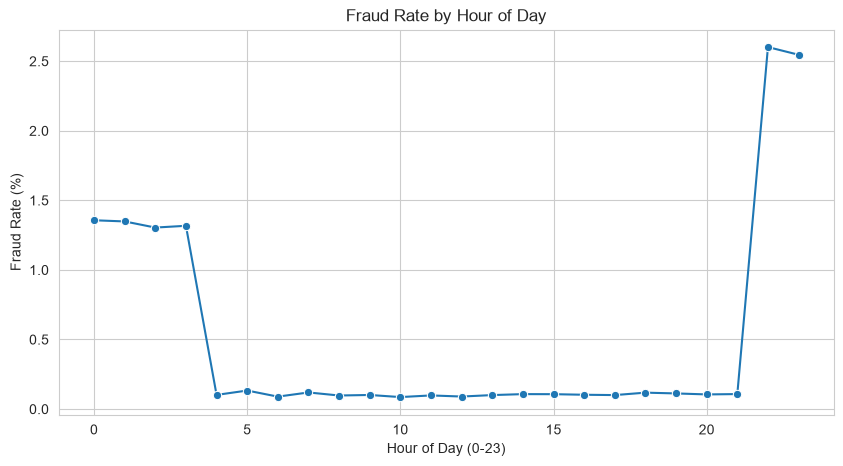

In [12]:
# fraud rate by hour
hour_fraud = df.groupby('trans_hour')['is_fraud'].mean() * 100

plt.figure(figsize=(10,5))
sns.lineplot(x=hour_fraud.index, y=hour_fraud.values, marker='o')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Hour of Day')
plt.show()

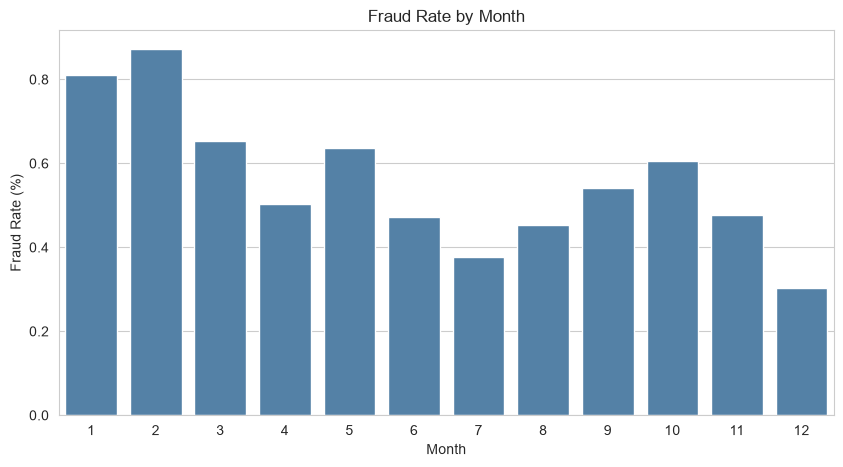

In [13]:

# fraud rate by month
month_fraud = df.groupby('trans_month')['is_fraud'].mean() * 100

plt.figure(figsize=(10,5))
sns.barplot(x=month_fraud.index, y=month_fraud.values, color='steelblue')
plt.xlabel('Month')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Month')
plt.show()

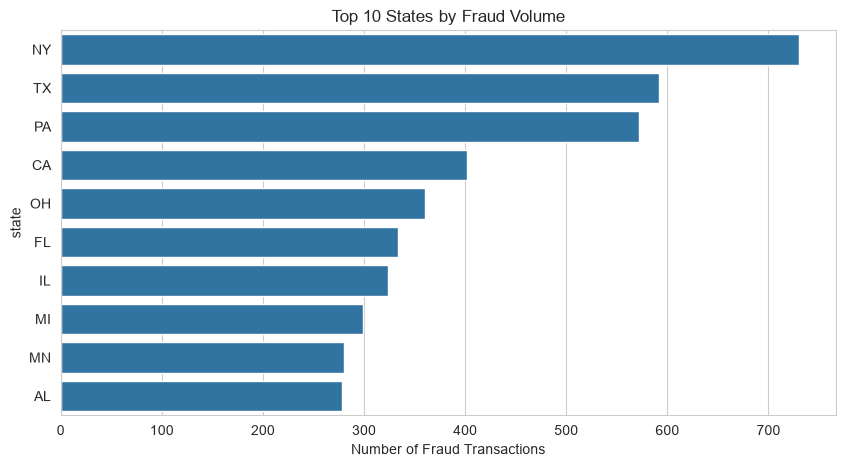

In [14]:
# fraud rate by state
state_fraud = df.groupby('state')['is_fraud'].agg(['sum','count'])
state_fraud = state_fraud.sort_values('sum', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=state_fraud['sum'], y=state_fraud.index)
plt.xlabel('Number of Fraud Transactions')
plt.title('Top 10 States by Fraud Volume')
plt.show()

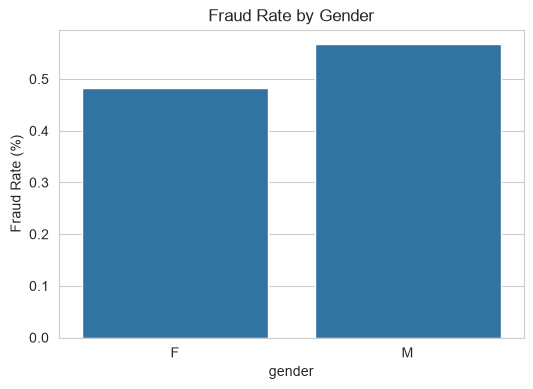

In [15]:
#fraude rate by gender
gender_fraud = df.groupby('gender')['is_fraud'].agg(['sum','count'])
gender_fraud['rate'] = gender_fraud['sum']/gender_fraud['count']*100

plt.figure(figsize=(6,4))
sns.barplot(x=gender_fraud.index, y=gender_fraud['rate'])
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Gender')
plt.show()

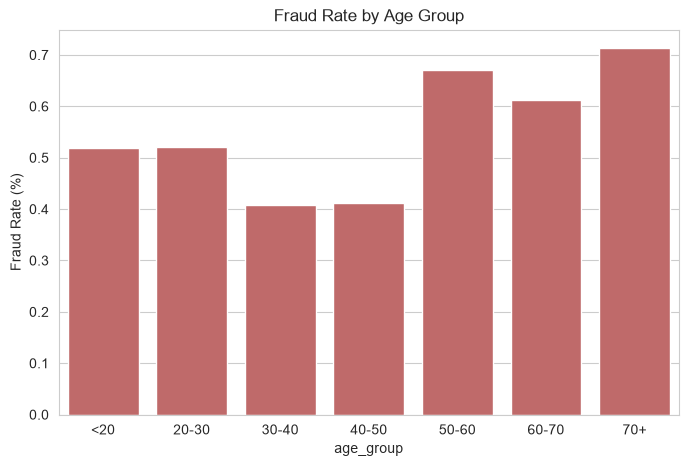

In [16]:

# Fraud by age group
bins = [0, 20, 30, 40, 50, 60, 70, 100]
labels = ['<20','20-30','30-40','40-50','50-60','60-70','70+']
df['age_group'] = pd.cut(df['customer_age'], bins=bins, labels=labels)

age_fraud = df.groupby('age_group')['is_fraud'].mean() * 100

plt.figure(figsize=(8,5))
sns.barplot(x=age_fraud.index, y=age_fraud.values, color='indianred')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Age Group')
plt.show()

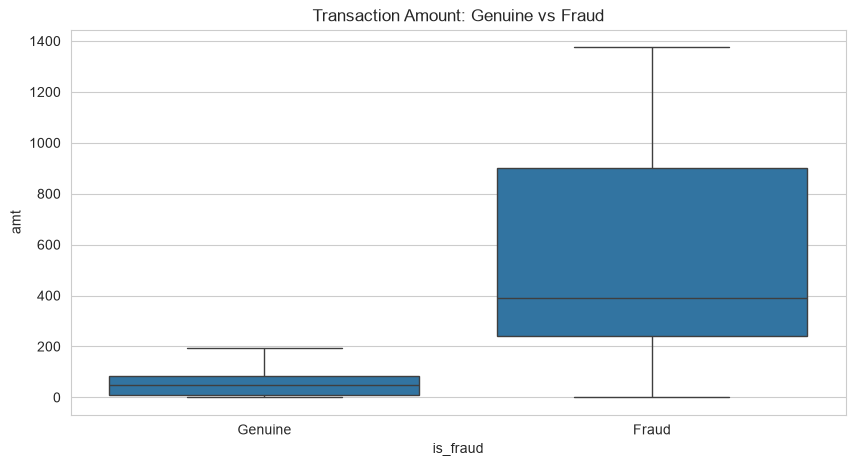

is_fraud
0     67.651278
1    530.661412
Name: amt, dtype: float64


In [18]:
#Transaction Amount Distribution (Fraud vs Genuine)
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='is_fraud', y='amt', showfliers=False)
plt.xticks([0,1], ['Genuine','Fraud'])
plt.title('Transaction Amount: Genuine vs Fraud')
plt.show()

print(df.groupby('is_fraud')['amt'].mean())

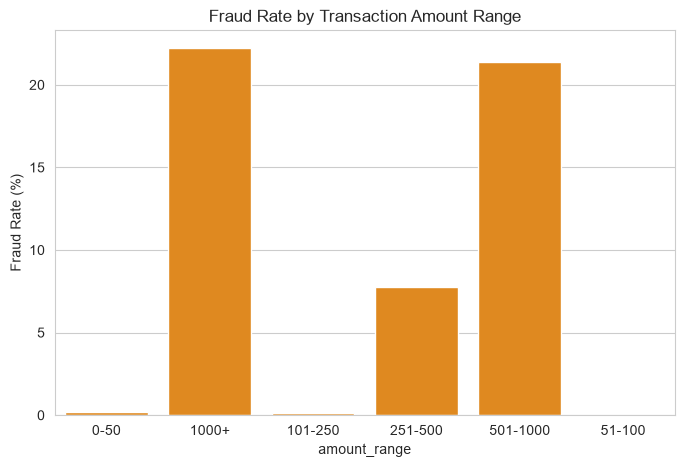

In [19]:
#Fraud Rate by Amount Range
amt_fraud = df.groupby('amount_range')['is_fraud'].mean().sort_index() * 100

plt.figure(figsize=(8,5))
sns.barplot(x=amt_fraud.index, y=amt_fraud.values, color='darkorange')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Transaction Amount Range')
plt.show()

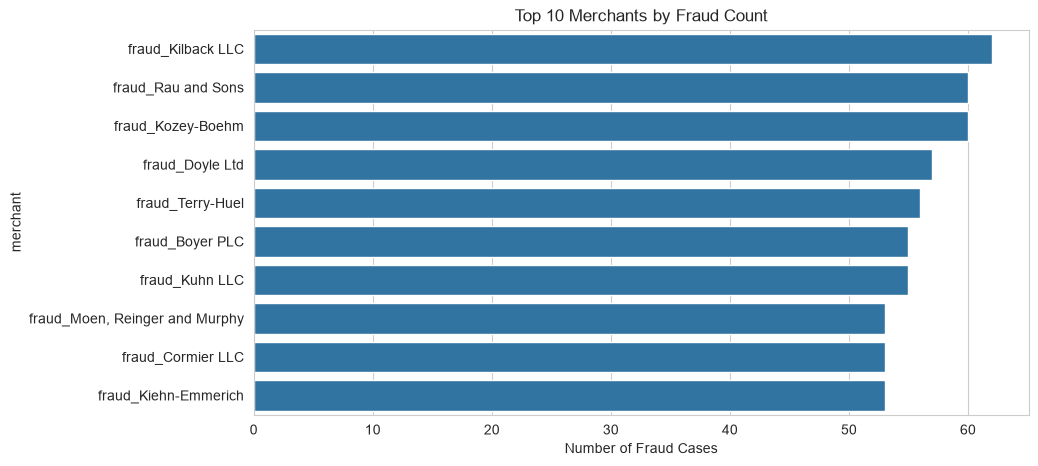

In [21]:

top_merchants = df[df['is_fraud']==1]['merchant'].value_counts().head(10)
# Top 10 merchaants by Fraud count
plt.figure(figsize=(10,5))
sns.barplot(x=top_merchants.values, y=top_merchants.index)
plt.xlabel('Number of Fraud Cases')
plt.title('Top 10 Merchants by Fraud Count')
plt.show()